# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Seminar 08: Writing Custom Datasets, DataLoaders and Transforms

A lot of effort in solving any machine learning problem goes in to
preparing the data. PyTorch provides many tools to make data loading
easy and hopefully, to make your code more readable. In this tutorial,
we will see how to load and preprocess/augment data from a non trivial
dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils
from PIL import Image

In [2]:
! wget https://download.pytorch.org/tutorial/faces.zip
! mkdir data
! unzip faces.zip -d data

--2026-02-12 08:21:24--  https://download.pytorch.org/tutorial/faces.zip
Resolving download.pytorch.org (download.pytorch.org)... 18.65.3.37, 18.65.3.71, 18.65.3.63, ...
Connecting to download.pytorch.org (download.pytorch.org)|18.65.3.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5780252 (5.5M) [application/zip]
Saving to: ‘faces.zip’

faces.zip           100%[===================>]   5.51M  10.0MB/s    in 0.6s    

2026-02-12 08:21:25 (10.0 MB/s) - ‘faces.zip’ saved [5780252/5780252]

Archive:  faces.zip
   creating: data/faces/
  inflating: data/faces/0805personali01.jpg  
  inflating: data/faces/1084239450_e76e00b7e7.jpg  
  inflating: data/faces/10comm-decarlo.jpg  
  inflating: data/faces/110276240_bec305da91.jpg  
  inflating: data/faces/1198_0_861.jpg  
  inflating: data/faces/137341995_e7c48e9a75.jpg  
  inflating: data/faces/1383023626_8a49e4879a.jpg  
  inflating: data/faces/144044282_87cf3ff76e.jpg  
  inflating: data/faces/152601997_ec6429a43c

The dataset we are going to deal with is that of facial pose.

Over all, 68 different landmark points are annotated for each face.

Download the dataset from https://download.pytorch.org/tutorial/faces.zip
    so that the images are in a directory named 'data/faces/'.
    This dataset was actually
    generated by applying excellent [dlib's pose
    estimation](https://blog.dlib.net/2014/08/real-time-face-pose-estimation.html)
    on a few images from imagenet tagged as 'face'.

Dataset comes with a csv file with annotations which looks like this:

```
    image_name,part_0_x,part_0_y,part_1_x,part_1_y,part_2_x, ... ,part_67_x,part_67_y
    0805personali01.jpg,27,83,27,98, ... 84,134
    1084239450_e76e00b7e7.jpg,70,236,71,257, ... ,128,312
```
Let's quickly read the CSV and get the annotations in an (N, 2) array where N
is the number of landmarks.




In [3]:
dataset_dir = Path("data/faces").resolve()
dataset_dir

PosixPath('/content/data/faces')

In [4]:
landmarks_frame = pd.read_csv(dataset_dir / "face_landmarks.csv")

n = 65
img_name = landmarks_frame.iloc[n, 0]
landmarks = np.array(landmarks_frame.iloc[n, 1:])
landmarks = landmarks.astype("float").reshape(-1, 2)

print("Image name: {}".format(img_name))
print("Landmarks shape: {}".format(landmarks.shape))
print("First 4 Landmarks:\n {}".format(landmarks[:4]))

Image name: person-7.jpg
Landmarks shape: (68, 2)
First 4 Landmarks:
 [[32. 65.]
 [33. 76.]
 [34. 86.]
 [34. 97.]]


Let's write a simple helper function to show an image and its landmarks
and use it to show a sample.




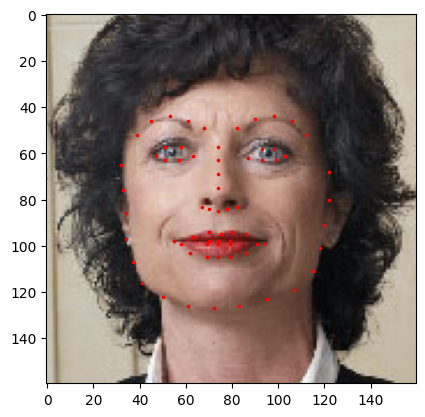

In [5]:
def show_landmarks(image, landmarks):
    """Show image with landmarks"""
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=10, marker=".", c="r")
    plt.pause(0.001)  # pause a bit so that plots are updated


plt.figure()
image = Image.open(dataset_dir / img_name)
show_landmarks(image, landmarks)
plt.show()

## Dataset class

[``torch.utils.data.Dataset``](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) is an abstract class representing a
dataset.

Your custom dataset should inherit ``Dataset`` and override the following
methods:

-  ``__len__`` so that ``len(dataset)`` returns the size of the dataset.
-  ``__getitem__`` to support the indexing such that ``dataset[i]`` can
   be used to get $i$\ th sample

Let's create a dataset class for our face landmarks dataset. We will
read the csv in ``__init__`` but leave the reading of images to
``__getitem__``. This is memory efficient because all the images are not
stored in the memory at once but read as required.

Sample of our dataset will be a dict
``{'image': image, 'landmarks': landmarks}``. Our dataset will take an
optional argument ``transform`` so that any required processing can be
applied on the sample. We will see the usefulness of ``transform`` in the
next section.

In [6]:
from typing import Callable, Any

In [14]:
class FaceLandmarksDataset(Dataset):
    """Dataset consisting in peoples' faces images and 68 points on them"""

    def __init__(self, root_dir: Path | str, transform: Callable | None = None):
        """
        Args:
            root_dir: Directory with all the images.
            transform: Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.landmarks_frame = pd.read_csv(self.root_dir / "face_landmarks.csv")
        self.transform = transform

    def __len__(self) -> int:
        return len(self.landmarks_frame)

    def __getitem__(self, idx: int | torch.Tensor) -> dict[str, Any]:
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = self.root_dir / self.landmarks_frame.iloc[idx, 0]
        image_obj = Image.open(img_name)
        image = np.array(image_obj)

        landmarks = self.landmarks_frame.iloc[idx, 1:]
        landmarks = np.array([landmarks])
        landmarks = landmarks.astype("float").reshape(-1, 2)

        sample = {"image": image, "landmarks": landmarks}

        if self.transform:
            sample = self.transform(sample)

        return sample

In [15]:
face_dataset = FaceLandmarksDataset(dataset_dir)

face_dataset[0].keys()

dict_keys(['image', 'landmarks'])

### [IterableDataset](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.IterableDataset)

In case your data comes from network (which is typical for large scale datasets (Terabytes and more) used for LLMs, VLMs, etc) you will need to implement `IterableDataset` interface by writing `__iter__` method.

In terms of Python you create a generator which `yield` data piece by piece.
Example of a generator could be `range` object (it also implements `__iter__` inside and we may use `iter` and `next` functions to get data.

In [16]:
def squares(n: int = 10): # implememts __iter__
    for i in range(n):
        yield i**2

iterator = iter(squares(4))
print(next(iterator))
print(next(iterator))
print(next(iterator))


print('\nFor loop:')

for sq in squares(5):
    print(sq)

0
1
4

For loop:
0
1
4
9
16


In [17]:
from torch.utils.data import IterableDataset


class FaceLandmarksIterableDataset(IterableDataset):
    """Face Landmarks dataset."""

    def __init__(self, root_dir: Path, transform: Callable | None = None):
        """
        Args:
            root_dir: Directory with all the images.
            transform: Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.landmarks_frame = pd.read_csv(self.root_dir / "face_landmarks.csv")
        self.transform = transform
        self.curr_index = 0

    def __iter__(self):
        img_name = self.root_dir / self.landmarks_frame.iloc[self.curr_index, 0]
        image_obj = Image.open(img_name)
        image = np.array(image_obj)

        landmarks = self.landmarks_frame.iloc[self.curr_index, 1:]
        landmarks = np.array([landmarks])
        landmarks = landmarks.astype("float").reshape(-1, 2)

        sample = {"image": image, "landmarks": landmarks}

        if self.transform:
            sample = self.transform(sample)

        yield sample

        self.curr_index += 1
        if self.curr_index == len(self.landmarks_frame):
            self.curr_index = 0

Let's instantiate this class and iterate through the data samples. We
will print the sizes of first 4 samples and show their landmarks.




0 (324, 215, 3) (68, 2)


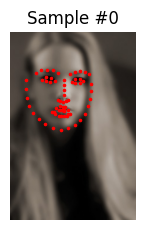

1 (500, 333, 3) (68, 2)


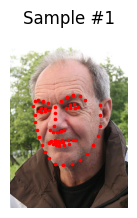

2 (250, 258, 3) (68, 2)


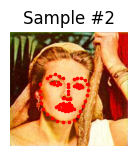

3 (434, 290, 3) (68, 2)


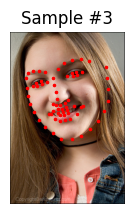

In [18]:
face_dataset = FaceLandmarksDataset(dataset_dir)

fig = plt.figure()

for i in range(3):
    sample = face_dataset[i]

    print(i, sample["image"].shape, sample["landmarks"].shape)

    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title("Sample #{}".format(i))
    ax.axis("off")
    show_landmarks(**sample)

plt.show()

## Transforms

One issue we can see from the above is that the samples are not of the
same size. Most neural networks expect the images of a fixed size.
Therefore, we will need to write some prepocessing code.
Let's create three transforms:

-  ``Rescale``: to scale the image
-  ``RandomCrop``: to crop from image randomly. This is data
   augmentation.
-  ``ToTensor``: to convert the numpy images to torch images (we need to
   swap axes).

We will write them as callable classes instead of simple functions so
that parameters of the transform need not be passed everytime it's
called. For this, we just need to implement ``__call__`` method and
if required, ``__init__`` method. We can then use a transform like this:


    tsfm = Transform(params)
    transformed_sample = tsfm(sample)

Observe below how these transforms had to be applied both on the image and
landmarks.




In [ ]:
class Rescale(object):
    """Rescale the image in a sample to a given size.

    Args:
        output_size (tuple or int): Desired output size. If tuple, output is
            matched to output_size. If int, smaller of image edges is matched
            to output_size keeping aspect ratio the same.
    """

    def __init__(self, output_size: int | tuple[int]):
        assert isinstance(output_size, (int, tuple))
        self.output_size = output_size

    def __call__(self, sample: dict[str, Any]):
        h, w = sample["image"].shape[:2]
        if isinstance(self.output_size, int):
            if h > w:
                new_h, new_w = self.output_size * h / w, self.output_size
            else:
                new_h, new_w = self.output_size, self.output_size * w / h
        else:
            new_h, new_w = self.output_size

        new_h, new_w = int(new_h), int(new_w)

        sample["image"] = transform.resize(sample["image"], (new_h, new_w))

        # h and w are swapped for landmarks because for images,
        # x and y axes are axis 1 and 0 respectively
        sample["landmarks"] = sample["landmarks"] * [new_w / w, new_h / h]

        return sample


class RandomCrop(object):
    """Crop randomly the image in a sample.

    Args:
        output_size (tuple or int): Desired output size. If int, square crop
            is made.
    """

    def __init__(self, output_size):
        assert isinstance(output_size, (int, tuple))
        if isinstance(output_size, int):
            self.output_size = (output_size, output_size)
        else:
            assert len(output_size) == 2
            self.output_size = output_size

    def __call__(self, sample):
        image, landmarks = sample["image"], sample["landmarks"]

        h, w = image.shape[:2]
        new_h, new_w = self.output_size

        top = np.random.randint(0, h - new_h)
        left = np.random.randint(0, w - new_w)

        image = image[top : top + new_h, left : left + new_w]

        landmarks = landmarks - [left, top]

        return {"image": image, "landmarks": landmarks}


class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        image, landmarks = sample["image"], sample["landmarks"]

        # swap color axis because
        # numpy image: H x W x C
        # torch image: C X H X W
        image = image.transpose((2, 0, 1))
        return {"image": torch.from_numpy(image), "landmarks": torch.from_numpy(landmarks)}

Compose transforms
~~~~~~~~~~~~~~~~~~

Now, we apply the transforms on a sample.

Let's say we want to rescale the shorter side of the image to 256 and
then randomly crop a square of size 224 from it. i.e, we want to compose
``Rescale`` and ``RandomCrop`` transforms.
``torchvision.transforms.Compose`` is a simple callable class which allows us
to do this.




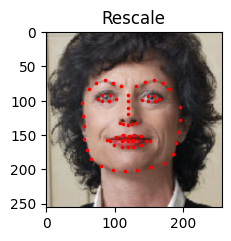

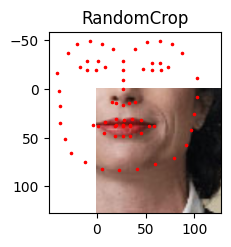

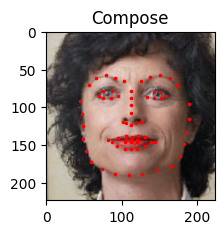

In [ ]:
scale = Rescale(256)
crop = RandomCrop(128)
composed = transforms.Compose([
    Rescale(256),
    RandomCrop(224),
])

# Apply each of the above transforms on sample.
fig = plt.figure()
sample = face_dataset[65]
for i, tsfrm in enumerate([scale, crop, composed]):
    transformed_sample = tsfrm(sample)

    ax = plt.subplot(1, 3, i + 1)
    plt.tight_layout()
    ax.set_title(type(tsfrm).__name__)
    show_landmarks(**transformed_sample)

plt.show()

Iterating through the dataset
-----------------------------

Let's put this all together to create a dataset with composed
transforms.
To summarize, every time this dataset is sampled:

-  An image is read from the file on the fly
-  Transforms are applied on the read image
-  Since one of the transforms is random, data is augmentated on
   sampling

We can iterate over the created dataset with a ``for i in range``
loop as before.




In [ ]:
transform_comp = transforms.Compose([Rescale(256), RandomCrop(224), ToTensor()])
transformed_dataset = FaceLandmarksDataset(
    dataset_dir,
    transform=transform_comp,
)

for i in range(len(transformed_dataset)):
    sample = transformed_dataset[i]

    print(i, sample.keys())
    print(i, sample["image"].size(), sample["landmarks"].size())

    if i == 3:
        break

0 dict_keys(['image', 'landmarks'])
0 torch.Size([3, 224, 224]) torch.Size([68, 2])
1 dict_keys(['image', 'landmarks'])
1 torch.Size([3, 224, 224]) torch.Size([68, 2])
2 dict_keys(['image', 'landmarks'])
2 torch.Size([3, 224, 224]) torch.Size([68, 2])
3 dict_keys(['image', 'landmarks'])
3 torch.Size([3, 224, 224]) torch.Size([68, 2])


However, we are losing a lot of features by using a simple ``for`` loop to
iterate over the data. In particular, we are missing out on:

-  Batching the data
-  Shuffling the data
-  Load the data in parallel using ``multiprocessing`` workers.

``torch.utils.data.DataLoader`` is an iterator which provides all these
features. Parameters used below should be clear. One parameter of
interest is ``collate_fn``. You can specify how exactly the samples need
to be batched using ``collate_fn``. However, default collate should work
fine for most use cases.




## Simple Dataset + DataLoader example

Demonstrate options we have in such classes

In [ ]:
class IntegerDataset(Dataset):
    def __init__(self, n: int = 10):
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, index: int) -> int:
        return {"data": np.random.randint(index + 1, size=3), "target": index}

        # return {
        #     "data": index,
        #     "target": {
        #         "brows": np.random.randint(index + 1),
        #         "lips": np.random.randint(index + 11),
        #     },
        # }

        # return index, np.random.randint(index + 1) # "data" and "target"

- batch_size
    - defined by hardware setup
    - Model_related_memory = Model_size + Optimizer + Other
    - batch_size = (GPU_RAM - Model_related_memory) / object_size
- num_workers
    - #CPU_cores * 2 - default value for full load
- shuffle
    - need for traing set to have random batcher every time
- drop_last
    - get rid of uneven batches
    - needed for full GPU usage
- pin_memory
    - uses memory dedicated to that process, so you will not experience data loss
- collate_fn
    - custom batch formation
    - still try to stick with default collator

In [ ]:
dataset = IntegerDataset(10)
dataloader = DataLoader(
    dataset, batch_size=3,
    shuffle=True,
    num_workers=2,
    drop_last=True,
    # pin_memory=True,
    # collate_fn=lambda x: x,
)

print("Dataset item content", dataset[0], "\n")
print("Naive batched data:", [dataset[0], dataset[1]], "\n")

all_data = set()

for i, batch in enumerate(dataloader):
    all_data.update(batch['data'])
    print("batch", i)
    print(batch)

# print("\nAll data:", sorted(all_data))

Dataset item content {'data': array([0, 0, 0]), 'target': 0} 

Naive batched data: [{'data': array([0, 0, 0]), 'target': 0}, {'data': array([0, 1, 0]), 'target': 1}] 



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


batch 0
{'data': tensor([[0, 0, 0],
        [1, 0, 3],
        [2, 0, 2]]), 'target': tensor([0, 3, 4])}
batch 1
{'data': tensor([[5, 2, 1],
        [3, 3, 0],
        [2, 8, 4]]), 'target': tensor([6, 7, 8])}
batch 2
{'data': tensor([[2, 1, 1],
        [0, 6, 2],
        [0, 0, 1]]), 'target': tensor([2, 9, 1])}


In [ ]:
class WeirdIntegerDataset(Dataset):
    def __init__(self, n: int = 10):
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, index: int) -> int:
        return {
            "data": index,
            "target": [np.random.randint(index + 11), np.random.randint(index + 11), np.random.randint(index + 11)]
            # "target": {
            #     "brows": np.random.randint(index + 1),
            #     "lips": np.random.randint(index + 11),
            # },
        }

        return index, np.random.randint(index + 1) # "data" and "target"

In [ ]:
def custom_collate(items: list):
    result = {"data": torch.tensor([item["data"] for item in items])}
    for i in range(3):
        result[f"Y_{i}"] = torch.tensor([item["target"][i] for item in items])
    # result = move_dict_to_device(result, device) # ???
    return result

In [ ]:
dataset = WeirdIntegerDataset(10)
dataloader = DataLoader(
    dataset,
    batch_size=3,
    # num_workers=2,
    drop_last=True,
    collate_fn=custom_collate,
)

print("Dataset item content", dataset[0], "\n")
print("Naive batched data:", [dataset[0], dataset[1]], "\n")

all_data = set()

for i, batch in enumerate(dataloader):
    all_data.update(batch['data'])
    print("batch", i)
    print(batch)

print("\nAll data:", sorted(all_data))

Dataset item content {'data': 0, 'target': [6, 7, 4]} 

Naive batched data: [{'data': 0, 'target': [0, 5, 4]}, {'data': 1, 'target': [6, 7, 5]}] 

batch 0
{'data': tensor([0, 1, 2]), 'Y_0': tensor([9, 6, 3]), 'Y_1': tensor([0, 3, 2]), 'Y_2': tensor([10, 11,  6])}
batch 1
{'data': tensor([3, 4, 5]), 'Y_0': tensor([ 2,  1, 15]), 'Y_1': tensor([ 9, 12, 15]), 'Y_2': tensor([ 2, 10, 10])}
batch 2
{'data': tensor([6, 7, 8]), 'Y_0': tensor([14,  8,  8]), 'Y_1': tensor([15, 10, 18]), 'Y_2': tensor([13,  6, 16])}

All data: [tensor(0), tensor(1), tensor(2), tensor(3), tensor(4), tensor(5), tensor(6), tensor(7), tensor(8)]


## Faces DataLoader

0 torch.Size([4, 3, 224, 224]) torch.Size([4, 68, 2])
1 torch.Size([4, 3, 224, 224]) torch.Size([4, 68, 2])
2 torch.Size([4, 3, 224, 224]) torch.Size([4, 68, 2])
3 torch.Size([4, 3, 224, 224]) torch.Size([4, 68, 2])


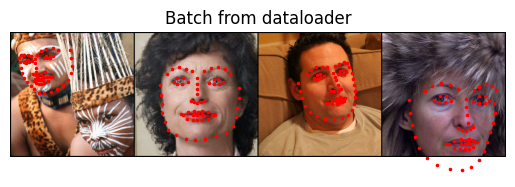

In [ ]:
dataloader = DataLoader(transformed_dataset, batch_size=4, shuffle=True, num_workers=2)


# Helper function to show a batch
def show_landmarks_batch(sample_batched):
    """Show image with landmarks for a batch of samples."""
    images_batch, landmarks_batch = sample_batched["image"], sample_batched["landmarks"]
    batch_size = len(images_batch)
    im_size = images_batch.size(2)
    grid_border_size = 2

    grid = utils.make_grid(images_batch)
    plt.imshow(grid.numpy().transpose((1, 2, 0)))

    for i in range(batch_size):
        plt.scatter(
            landmarks_batch[i, :, 0].numpy() + i * im_size + (i + 1) * grid_border_size,
            landmarks_batch[i, :, 1].numpy() + grid_border_size,
            s=10,
            marker=".",
            c="r",
        )

        plt.title("Batch from dataloader")


for i_batch, sample_batched in enumerate(dataloader):
    print(i_batch, sample_batched["image"].size(), sample_batched["landmarks"].size())

    # observe 4th batch and stop.
    if i_batch == 3:
        plt.figure()
        show_landmarks_batch(sample_batched)
        plt.axis("off")
        plt.ioff()
        plt.show()
        break

Typical code for Neural Network training:

In [ ]:
dataloader = Dataloader(...)

for epoch in range(num_epochs):
    for iteration, batch in enumerate(dataloader):
        batch = batch.to(device) # send to GPU

        optimizer.zero_grads()
        prediction = model(batch)
        loss = criterion(prediction)
        loss.backward()
        optimizer.step()

    scheduler.step()

Afterword: torchvision
----------------------

In this tutorial, we have seen how to write and use datasets, transforms
and dataloader. ``torchvision`` package provides some common datasets and
transforms. You might not even have to write custom classes. One of the
more generic datasets available in torchvision is ``ImageFolder``.
It assumes that images are organized in the following way: ::

    root/ants/xxx.png
    root/ants/xxy.jpeg
    root/ants/xxz.png
    .
    .
    .
    root/bees/123.jpg
    root/bees/nsdf3.png
    root/bees/asd932_.png

where 'ants', 'bees' etc. are class labels. Similarly generic transforms
which operate on ``PIL.Image`` like  ``RandomHorizontalFlip``, ``Scale``,
are also available. You can use these to write a dataloader like this: ::

  import torch
  from torchvision import transforms, datasets

  data_transform = transforms.Compose([
          transforms.RandomSizedCrop(224),
          transforms.RandomHorizontalFlip(),
          transforms.ToTensor(),
          transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
      ])
  hymenoptera_dataset = datasets.ImageFolder(root='hymenoptera_data/train',
                                             transform=data_transform)
  dataset_loader = torch.utils.data.DataLoader(hymenoptera_dataset,
                                               batch_size=4, shuffle=True,
                                               num_workers=4)

For an example with training code, please see
:doc:`transfer_learning_tutorial`.



### Credentials

Based on material by [Sasank Chilamkurthy](https://chsasank.github.io)
